Importing the Libraries

In [27]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import warnings
warnings.filterwarnings("ignore")
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns
from sklearn.model_selection import train_test_split

In [28]:
from tensorflow.keras.layers import Conv2D , BatchNormalization, Activation , MaxPool2D , Conv2DTranspose ,Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dropout

Loading the Dataset

In [29]:
data_path = r"C:\Users\GOD\Desktop\CV & RL\Brain Tumor Segmentation Dataset"

In [30]:
import os
import glob  

img_dir = r"C:\Users\GOD\Desktop\CV & RL\Brain Tumor Segmentation Dataset\image"
mask_dir = r"C:\Users\GOD\Desktop\CV & RL\Brain Tumor Segmentation Dataset\mask"
image_files = sorted(glob.glob(os.path.join(img_dir, "*/*.jpg")))
mask_files  = sorted(glob.glob(os.path.join(mask_dir, "*/*.jpg")))

img_base_to_path  = {os.path.splitext(os.path.basename(f))[0]: f for f in image_files}
mask_base_to_path = {os.path.splitext(os.path.basename(f))[0].replace('_m',''): f for f in mask_files}

common_basenames = sorted(set(img_base_to_path) & set(mask_base_to_path))
paired_images = [img_base_to_path[b] for b in common_basenames]
paired_masks  = [mask_base_to_path[b] for b in common_basenames]

print(f"Paired images: {len(paired_images)}")
print(f"Paired masks: {len(paired_masks)}")

Paired images: 4237
Paired masks: 4237


Image Preprocessing

In [31]:
from PIL import Image
import numpy as np

IMG_SIZE = 128
N_SAMPLES = len(paired_images)

def load_image_mask(img_path, mask_path, img_size=IMG_SIZE):
    img = Image.open(img_path).convert('L').resize((img_size, img_size))
    img = np.array(img, dtype=np.float32) / 255.0  # (128,128)
    img = np.expand_dims(img, axis=-1)             # (128,128,1)
    
   
    mask = Image.open(mask_path).convert('L').resize((img_size, img_size))
    mask = np.array(mask, dtype=np.float32) / 255.0
    mask = (mask > 0.5).astype(np.float32)          # Binary: 0 or 1
    mask = np.expand_dims(mask, axis=-1)            # (128,128,1) 
    
    return img, mask


X = np.zeros((N_SAMPLES, IMG_SIZE, IMG_SIZE, 1), dtype=np.float32)  
Y = np.zeros((N_SAMPLES, IMG_SIZE, IMG_SIZE, 1), dtype=np.float32)  


for i, (img_path, mask_path) in enumerate(zip(paired_images, paired_masks)):
    X[i], Y[i] = load_image_mask(img_path, mask_path)
    if i % 100 == 0:
        print(f"Loaded {i+1}/{N_SAMPLES} images")

print(" Final shapes:")
print(f"X (MRI): {X.shape}")      
print(f"Y (Mask): {Y.shape}")     
print(f"X range: {X.min():.3f} to {X.max():.3f}")
print(f"Y binary: {np.unique(Y)}")  # [0. 1.]

Loaded 1/4237 images
Loaded 101/4237 images
Loaded 201/4237 images
Loaded 301/4237 images
Loaded 401/4237 images
Loaded 501/4237 images
Loaded 601/4237 images
Loaded 701/4237 images
Loaded 801/4237 images
Loaded 901/4237 images
Loaded 1001/4237 images
Loaded 1101/4237 images
Loaded 1201/4237 images
Loaded 1301/4237 images
Loaded 1401/4237 images
Loaded 1501/4237 images
Loaded 1601/4237 images
Loaded 1701/4237 images
Loaded 1801/4237 images
Loaded 1901/4237 images
Loaded 2001/4237 images
Loaded 2101/4237 images
Loaded 2201/4237 images
Loaded 2301/4237 images
Loaded 2401/4237 images
Loaded 2501/4237 images
Loaded 2601/4237 images
Loaded 2701/4237 images
Loaded 2801/4237 images
Loaded 2901/4237 images
Loaded 3001/4237 images
Loaded 3101/4237 images
Loaded 3201/4237 images
Loaded 3301/4237 images
Loaded 3401/4237 images
Loaded 3501/4237 images
Loaded 3601/4237 images
Loaded 3701/4237 images
Loaded 3801/4237 images
Loaded 3901/4237 images
Loaded 4001/4237 images
Loaded 4101/4237 images
Load

In [32]:
X_train, X_tmp, Y_train, Y_tmp = train_test_split(X, Y, test_size=0.2, random_state=42)

#
X_val, X_test, Y_val, Y_test = train_test_split(X_tmp, Y_tmp, test_size=0.5, random_state=42)

print("Trainin the Model:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)


Trainin the Model: (3389, 128, 128, 1)
Validation: (424, 128, 128, 1)
Testing: (424, 128, 128, 1)


U-NET Architecture

In [33]:
def convolution_block(inputs,num_filters, dropout_rate=0.0):
  #1st Convolution  Layer
  x=Conv2D(num_filters, 3, padding="same")(inputs)
  x=BatchNormalization()(x)
  x=Activation('relu')(x)

  if dropout_rate > 0:
        x = Dropout(dropout_rate)(x)

  #2nd Convolution Layer
  x=Conv2D(num_filters,3,padding='same')(x)
  x=BatchNormalization()(x)
  x=Activation('relu')(x)

  return x

Enoder

In [34]:
def encoder(inputs,num_filters):
  #x act as skip connection
  x=convolution_block(inputs,num_filters)
  p=MaxPool2D((2,2))(x)
  return x,p

Decoder

In [35]:
#Here we need skip connection to resize the image
def decoder(inputs, skip_features , num_filters):
  #Since we need to reconstruct the image so we use strides - 2

  x=Conv2DTranspose(num_filters,(2,2),strides=2, padding='same')(inputs)
  #Combine transpose input and skipconnection from encoder
  x= Concatenate()([x,skip_features])
  x=convolution_block(x,num_filters)
  return x


In [36]:
def built_unet(input_shape):
  inputs = Input(input_shape)

  #s- convolution layer , p- pooling layer
  s1, p1 = encoder(inputs,64)#64- kernal
  s2, p2 = encoder(p1,128)
  s3, p3 = encoder(p2, 256)
  s4, p4 = encoder(p3, 512)

  #print(s1.shape, s2.shape ,  s3.shape , s4.shape)
  #print(p1.shape , p2.shape, p3.shape , p4.shape)

  #built unet
  b1= convolution_block(p4,1024)

  d1=decoder(b1,s4,512)
  d2=decoder(d1,s3,256)
  d3=decoder(d2,s2,128)
  d4=decoder(d3,s1,64)

 # print(d4.shape)

  outputs = Conv2D(1,1,padding='same',activation='sigmoid')(d4)
  print(outputs.shape)

  model = Model(inputs, outputs, name='UNet')
  return model

if __name__ == "__main__":
  input_shape = (128,128,1) # Changed input_shape to match IMG_SIZE
  model = built_unet(input_shape) # Changed unet_model to model
  model.summary()

(None, 128, 128, 1)


Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 128, 128,  │     36,928 │ activation_18[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │    147,584 │ activation_20[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ activation_21[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_23[0][0] 

 Total params: 31,054,145 (118.46 MB)

 Trainable params: 31,042,369 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [37]:
#Dice Loss
def dice_loss(y_true, y_pred, smooth=1e-5):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
# BCE + DICE LOSS
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

#Dice coefficient
def dice_coef(y_true, y_pred, smooth=1e-5):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def iou_metric(y_true, y_pred, smooth=1e-5):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)



model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=['accuracy', dice_coef, iou_metric]
)


In [38]:
def iou_score(y_true, y_pred):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + K.epsilon()) / (union + K.epsilon())

In [39]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=['accuracy', dice_coef, iou_score])


checkpoint_path = 'unet_best_weights.keras'
callbacks = [
    EarlyStopping(monitor='val_dice_coef', patience=8, mode='max', restore_best_weights=True, verbose=1),
    ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_dice_coef', mode='max', verbose=1)
]


history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=10,
    batch_size=8,
    callbacks=callbacks
)


model.save("unet_brain_segmentation.keras")

Epoch 1/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8111 - dice_coef: 0.0291 - iou_score: 0.0149 - loss: 1.4054
Epoch 1: val_dice_coef improved from None to 0.02691, saving model to unet_best_weights.keras

Epoch 1: finished saving model to unet_best_weights.keras
424/424 ━━━━━━━━━━━━━━━━━━━━ 2164s 5s/step - accuracy: 0.9416 - dice_coef: 0.0456 - iou_score: 0.0236 - loss: 1.2110 - val_accuracy: 0.9862 - val_dice_coef: 0.0269 - val_iou_score: 0.0137 - val_loss: 1.1363
Epoch 2/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9885 - dice_coef: 0.1212 - iou_score: 0.0655 - loss: 0.9966
Epoch 2: val_dice_coef improved from 0.02691 to 0.22203, saving model to unet_best_weights.keras

Epoch 2: finished saving model to unet_best_weights.keras
424/424 ━━━━━━━━━━━━━━━━━━━━ 1348s 3s/step - accuracy: 0.9897 - dice_coef: 0.1470 - iou_score: 0.0807 - loss: 0.9534 - val_accuracy: 0.9908 - val_dice_coef: 0.2220 - val_iou_score: 0.1275 - val_loss: 0.8537
Epoch 3/10
424/424 ━━━━━━━━

Load the Saved Model

In [40]:
model = load_model("unet_brain_segmentation.keras", compile=False)

Utility Metrics

In [41]:
def dice_score_np(y_true, y_pred, smooth=1e-7):
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)
    intersection = np.sum(y_true * y_pred)
    return (2.0 * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)

In [42]:
def iou_score_np(y_true, y_pred, smooth=1e-7):
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

Uncertatinity estimaton -Mc Dropout Style

In [43]:
def mc_dropout_uncertainty(model, x, n_samples=10, batch_size=8):
    preds = []
    for _ in range(n_samples):
        batch_preds = []
        for i in range(0, len(x), batch_size):
            xb = x[i:i+batch_size]
            pred = model(xb, training=True).numpy()
            batch_preds.append(pred)
        preds.append(np.concatenate(batch_preds, axis=0))

    preds = np.array(preds)
    mean_pred = np.mean(preds, axis=0)
    var_pred = np.var(preds, axis=0)
    uncertainty = np.mean(var_pred, axis=(1, 2, 3))
    return mean_pred, uncertainty

Thompson Sampling

In [44]:
def thompson_select(model, pool_X, n_select=20, n_mc=10, seed=None):
    rng = np.random.default_rng(seed)
    remaining_idx = list(range(len(pool_X)))
    selected_idx = []
    pool_copy = pool_X.copy()

    for _ in range(min(n_select, len(pool_copy))):
        _, uncertainty = mc_dropout_uncertainty(model, pool_copy, n_samples=n_mc)
        sampled_scores = uncertainty + rng.normal(0, 0.01, size=len(uncertainty))
        pick_local = int(np.argmax(sampled_scores))
        pick_global = remaining_idx[pick_local]

        selected_idx.append(pick_global)
        pool_copy = np.delete(pool_copy, pick_local, axis=0)
        remaining_idx.pop(pick_local)

        if len(pool_copy) == 0:
            break

    return selected_idx

Simulate Labeling

In [64]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, poolX, Y_train, poolY = train_test_split(X_train, Y_train, test_size=0.2, random_state=42)

# Now that poolX exists, this will run without the NameError
pool_size = len(poolX)
subsample_size = min(200, pool_size)

subsample_idx = np.random.choice(pool_size, size=subsample_size, replace=False)
X_sub = poolX[subsample_idx]
Y_sub = poolY[subsample_idx]

selected_subindices = thompson_select(
    model,
    X_sub,
    n_select=5,
    n_mc=1,
    seed=42
)

selected_indices = subsample_idx[selected_subindices]
X_selected = poolX[selected_indices]
Y_selected = poolY[selected_indices]

mask = np.ones(pool_size, dtype=bool)
mask[selected_indices] = False

X_remaining = poolX[mask]
Y_remaining = poolY[mask]

In [65]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=['accuracy', dice_coef, iou_score]
)

X_aug = np.concatenate([X_train, X_selected], axis=0)
Y_aug = np.concatenate([Y_train, Y_selected], axis=0)

history_al = model.fit(
    X_aug, Y_aug,
    validation_data=(X_test, Y_test),
    epochs=5,
    batch_size=8,
    verbose=1
)

Epoch 1/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 501s 7s/step - accuracy: 0.9973 - dice_coef: 0.8479 - iou_score: 0.7455 - loss: 0.1684 - val_accuracy: 0.9971 - val_dice_coef: 0.8193 - val_iou_score: 0.7096 - val_loss: 0.1992
Epoch 2/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 368s 5s/step - accuracy: 0.9975 - dice_coef: 0.8489 - iou_score: 0.7587 - loss: 0.1676 - val_accuracy: 0.9971 - val_dice_coef: 0.8204 - val_iou_score: 0.7129 - val_loss: 0.1976
Epoch 3/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 480s 7s/step - accuracy: 0.9975 - dice_coef: 0.8619 - iou_score: 0.7737 - loss: 0.1525 - val_accuracy: 0.9971 - val_dice_coef: 0.8134 - val_iou_score: 0.7003 - val_loss: 0.2037
Epoch 4/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 473s 7s/step - accuracy: 0.9977 - dice_coef: 0.8725 - iou_score: 0.7856 - loss: 0.1417 - val_accuracy: 0.9971 - val_dice_coef: 0.8280 - val_iou_score: 0.7200 - val_loss: 0.1898
Epoch 5/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 398s 6s/step - accuracy: 0.9975 - dice_coef: 0.8598 - iou_score: 0.7662 - loss: 0.1524 - val_accuracy: 0.99

Evaluate the Model

In [66]:
test_loss, test_acc, test_dice, test_iou = model.evaluate(X_test, Y_test, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)
print("Test dice:", test_dice)
print("Test iou:", test_iou)

14/14 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.9973 - dice_coef: 0.8389 - iou_score: 0.7295 - loss: 0.1779
Test loss: 0.1779366433620453
Test accuracy: 0.9972728490829468
Test dice: 0.838852047920227
Test iou: 0.7294676899909973


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction shape: (1, 128, 128, 1)


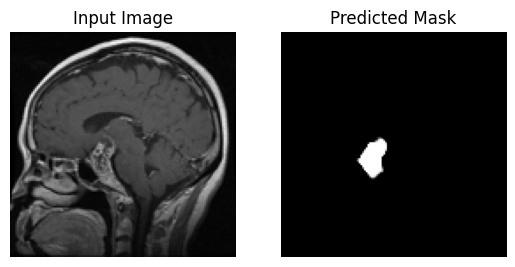

In [48]:
import numpy as np
import matplotlib.pyplot as plt

img = X_test[0]                       # or any new image with shape (128,128,1)
img_input = np.expand_dims(img, axis=0)

pred = model.predict(img_input)
pred_mask = pred[0]

print("Prediction shape:", pred.shape)

plt.subplot(1, 2, 1)
plt.imshow(img.squeeze(), cmap='gray')
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(pred_mask.squeeze(), cmap='gray')
plt.title("Predicted Mask")
plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step


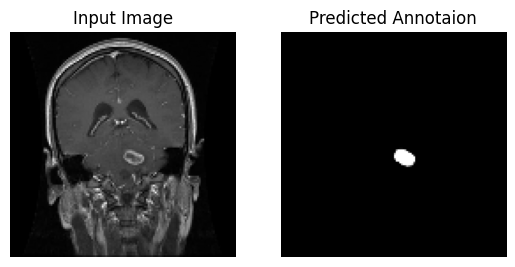

In [49]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

img = load_img(
    r"C:\Users\GOD\Desktop\CV & RL\Brain Tumor Segmentation Dataset\image\1\Tr-gl_0014.jpg",
    color_mode="grayscale",
    target_size=(128, 128)
)
img = img_to_array(img) / 255.0
img_input = np.expand_dims(img, axis=0)

pred = model.predict(img_input)
pred_mask = pred[0]

plt.subplot(1, 2, 1)
plt.imshow(img.squeeze(), cmap='gray')
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(pred_mask.squeeze(), cmap='gray')
plt.title("Predicted Annotaion")
plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step


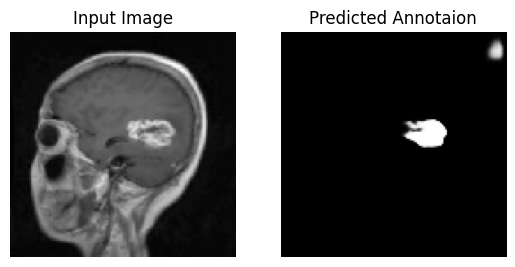

In [50]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

img = load_img(
    r"Example.png",
    color_mode="grayscale",
    target_size=(128, 128)
)
img = img_to_array(img) / 255.0
img_input = np.expand_dims(img, axis=0)

pred = model.predict(img_input)
pred_mask = pred[0]

plt.subplot(1, 2, 1)
plt.imshow(img.squeeze(), cmap='gray')
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(pred_mask.squeeze(), cmap='gray')
plt.title("Predicted Annotaion")
plt.axis('off')

plt.show()

In [52]:
model.save("braintumor_segmentation.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step


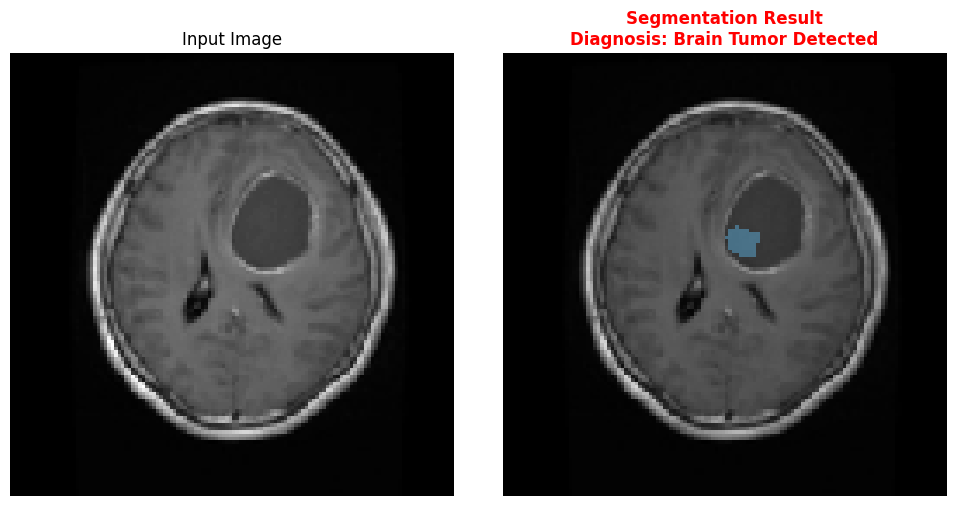

In [53]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 1. Load and process the image
img = load_img(
    r"Sample_Image_2.png",
    color_mode="grayscale",
    target_size=(128, 128)
)
img = img_to_array(img) / 255.0
img_input = np.expand_dims(img, axis=0)

# 2. Predict the mask
pred = model.predict(img_input)
pred_mask = pred[0]
mask_bin = pred_mask.squeeze() > 0.5

# ---------------------------------------------------------
# NEW: DIAGNOSIS LOGIC
# Count how many pixels the model thinks are a tumor. 
# We use a small threshold (e.g., 50 pixels) to ignore random noise.
tumor_pixel_count = np.sum(mask_bin)

if tumor_pixel_count > 50:
    diagnosis = "Brain Tumor Detected"
    title_color = "red"
else:
    diagnosis = "No Tumor Detected"
    title_color = "green"
# ---------------------------------------------------------

# 3. Create the visual overlay
image_rgb = np.stack([img.squeeze(), img.squeeze(), img.squeeze()], axis=-1)
image_rgb = (image_rgb * 255).astype(np.uint8)

overlay = image_rgb.copy()
overlay[mask_bin] = (100, 200, 255)  

blended = cv2.addWeighted(image_rgb, 0.6, overlay, 0.4, 0)

# 4. Display the results
plt.figure(figsize=(10, 5)) # Make the figure slightly wider

plt.subplot(1, 2, 1)
plt.imshow(img.squeeze(), cmap='gray')
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(blended)
# Add the diagnosis to the title, changing color based on the result!
plt.title(f"Segmentation Result\nDiagnosis: {diagnosis}", color=title_color, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

In [54]:
"""import numpy as np

# Predict on test set
y_pred = model.predict(X_test)

# Convert probabilities to binary masks
y_pred_bin = (y_pred > 0.5).astype(np.float32)
Y_test_bin = (Y_test > 0.5).astype(np.float32)

# Pixel-wise accuracy
acc = np.mean(y_pred_bin == Y_test_bin)
print("Pixel Accuracy:", acc)

# Dice coefficient
def dice_coef(y_true, y_pred, smooth=1e-7):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)

dice = dice_coef(Y_test_bin, y_pred_bin)
print("Dice Coefficient:", dice)

# IoU
def iou_score(y_true, y_pred, smooth=1e-7):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

iou = iou_score(Y_test_bin, y_pred_bin)
print("IoU:", iou)
"""

'import numpy as np\n\n# Predict on test set\ny_pred = model.predict(X_test)\n\n# Convert probabilities to binary masks\ny_pred_bin = (y_pred > 0.5).astype(np.float32)\nY_test_bin = (Y_test > 0.5).astype(np.float32)\n\n# Pixel-wise accuracy\nacc = np.mean(y_pred_bin == Y_test_bin)\nprint("Pixel Accuracy:", acc)\n\n# Dice coefficient\ndef dice_coef(y_true, y_pred, smooth=1e-7):\n    y_true = y_true.flatten()\n    y_pred = y_pred.flatten()\n    intersection = np.sum(y_true * y_pred)\n    return (2. * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)\n\ndice = dice_coef(Y_test_bin, y_pred_bin)\nprint("Dice Coefficient:", dice)\n\n# IoU\ndef iou_score(y_true, y_pred, smooth=1e-7):\n    y_true = y_true.flatten()\n    y_pred = y_pred.flatten()\n    intersection = np.sum(y_true * y_pred)\n    union = np.sum(y_true) + np.sum(y_pred) - intersection\n    return (intersection + smooth) / (union + smooth)\n\niou = iou_score(Y_test_bin, y_pred_bin)\nprint("IoU:", iou)\n'

Accuaracy ,Precision ,Recall,F1 score

In [67]:
# Predict on test set
y_pred = model.predict(X_test)

# Threshold predictions
y_pred_bin = (y_pred > 0.5).astype(np.float32)
y_true_bin = Y_test.astype(np.float32)

# Flatten for sklearn metrics if needed
y_true_flat = y_true_bin.reshape(-1)
y_pred_flat = y_pred_bin.reshape(-1)

# Better segmentation metrics
test_dice = dice_score_np(y_true_bin, y_pred_bin)
test_iou = iou_score_np(y_true_bin, y_pred_bin)

print("Test Dice Coefficient:", test_dice)
print("Test IoU Score:", test_iou)

14/14 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step
Test Dice Coefficient: 0.85583615
Test IoU Score: 0.74800146


In [68]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predict on test set
y_pred = model.predict(X_test)

# Convert prediction and ground truth masks to binary
y_pred_bin = (y_pred > 0.5).astype(np.uint8)
y_true_bin = (Y_test > 0.5).astype(np.uint8)

# Flatten masks
y_pred_flat = y_pred_bin.flatten()
y_true_flat = y_true_bin.flatten()

# Segmentation metrics (PRIMARY)
test_dice = dice_score_np(y_true_bin, y_pred_bin)
test_iou  = iou_score_np(y_true_bin, y_pred_bin)

# Classification-style metrics (SECONDARY)
accuracy  = accuracy_score(y_true_flat, y_pred_flat)
precision = precision_score(y_true_flat, y_pred_flat, zero_division=0)
recall    = recall_score(y_true_flat, y_pred_flat, zero_division=0)
f1        = f1_score(y_true_flat, y_pred_flat, zero_division=0)

# ── detailed prints ──
print("Test Dice Coefficient :", round(test_dice, 4))
print("Test IoU Score        :", round(test_iou,  4))
print("Pixel Accuracy        :", round(accuracy,  4))
print("Precision             :", round(precision, 4))
print("Recall                :", round(recall,    4))
print("F1 Score              :", round(f1,        4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true_flat, y_pred_flat))

print("\nClassification Report:")
print(classification_report(
    y_true_flat,
    y_pred_flat,
    target_names=["Background", "Tumor"],
    zero_division=0
))

# ── KEY RESULTS SUMMARY (add this) ──
print("=" * 40)
print("       KEY RESULTS SUMMARY")
print("=" * 40)
print(f"  Dice Coefficient : {test_dice:.4f}  ← PRIMARY")
print(f"  IoU Score        : {test_iou:.4f}  ← SECONDARY")
print(f"  F1 Score         : {f1:.4f}")
print(f"  Pixel Accuracy   : {accuracy:.4f}  ← not reliable alone")
print("=" * 40)

# ── Performance interpretation ──
if test_dice >= 0.85:
    print("Excellent segmentation performance")
elif test_dice >= 0.75:
    print("Good segmentation performance")
elif test_dice >= 0.60:
    print("Moderate — consider more epochs or augmentation")
else:
    print("Low — review model architecture or data quality")

14/14 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step
Test Dice Coefficient : 0.8558
Test IoU Score        : 0.748
Pixel Accuracy        : 0.9973
Precision             : 0.9382
Recall                : 0.7868
F1 Score              : 0.8558

Confusion Matrix:
[[6871637    3704]
 [  15241   56234]]

Classification Report:
              precision    recall  f1-score   support

  Background       1.00      1.00      1.00   6875341
       Tumor       0.94      0.79      0.86     71475

    accuracy                           1.00   6946816
   macro avg       0.97      0.89      0.93   6946816
weighted avg       1.00      1.00      1.00   6946816

       KEY RESULTS SUMMARY
  Dice Coefficient : 0.8558  ← PRIMARY
  IoU Score        : 0.7480  ← SECONDARY
  F1 Score         : 0.8558
  Pixel Accuracy   : 0.9973  ← not reliable alone
Excellent segmentation performance


Visualization

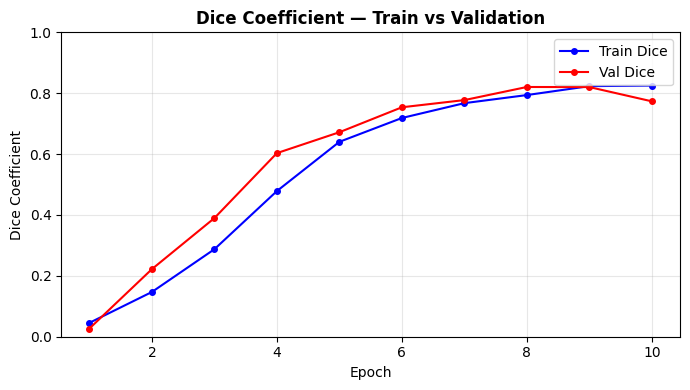

In [69]:
epochs = range(1, len(history.history['dice_coef']) + 1)
 
plt.figure(figsize=(7, 4))
plt.plot(epochs, history.history['dice_coef'],     'b-o', markersize=4, label='Train Dice')
plt.plot(epochs, history.history['val_dice_coef'], 'r-o', markersize=4, label='Val Dice')
plt.title('Dice Coefficient — Train vs Validation', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('plot1_dice.png', dpi=150)
plt.show()

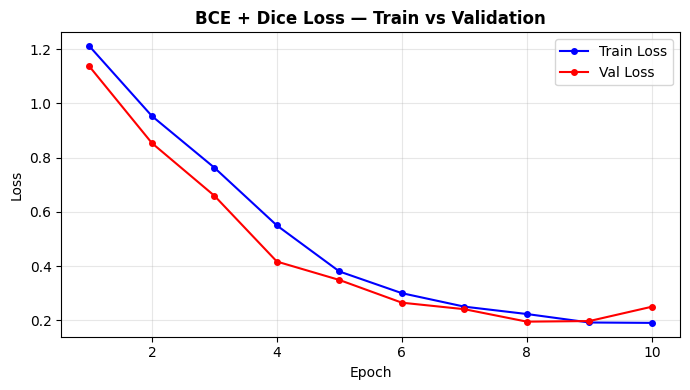

In [70]:
epochs = range(1, len(history.history['loss']) + 1)
 
plt.figure(figsize=(7, 4))
plt.plot(epochs, history.history['loss'],     'b-o', markersize=4, label='Train Loss')
plt.plot(epochs, history.history['val_loss'], 'r-o', markersize=4, label='Val Loss')
plt.title('BCE + Dice Loss — Train vs Validation', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot2_loss.png', dpi=150)
plt.show()
 

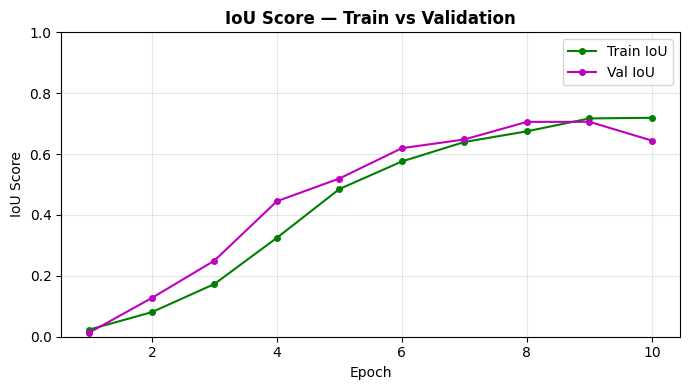

In [71]:
epochs = range(1, len(history.history['iou_score']) + 1)
 
plt.figure(figsize=(7, 4))
plt.plot(epochs, history.history['iou_score'],     'g-o', markersize=4, label='Train IoU')
plt.plot(epochs, history.history['val_iou_score'], 'm-o', markersize=4, label='Val IoU')
plt.title('IoU Score — Train vs Validation', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('IoU Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('plot3_iou.png', dpi=150)
plt.show()

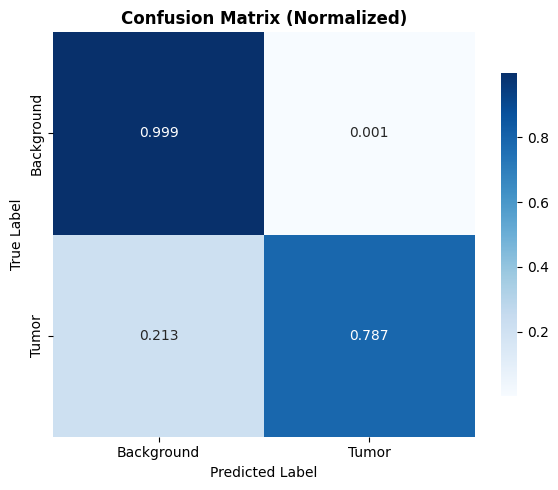

In [72]:
cm = confusion_matrix(y_true_flat, y_pred_flat)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
 
plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=['Background', 'Tumor'],
            yticklabels=['Background', 'Tumor'],
            cbar_kws={'shrink': 0.8})
plt.title('Confusion Matrix (Normalized)', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('plot4_confusion_matrix.png', dpi=150)
plt.show()

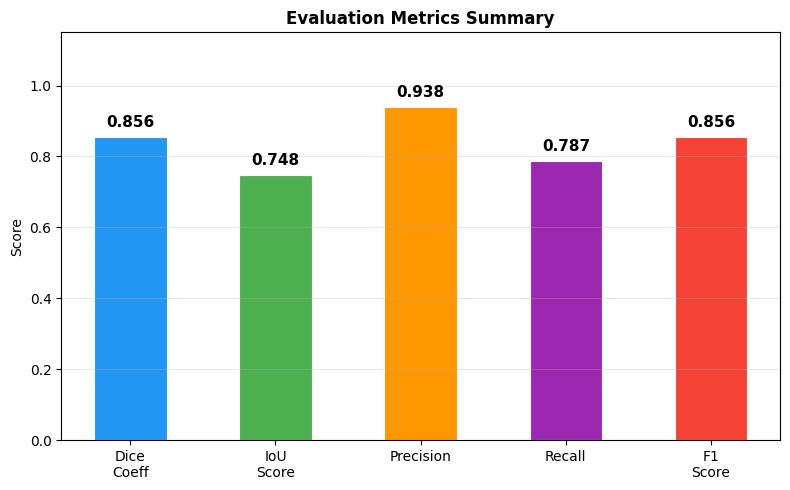

In [73]:
metrics_names  = ['Dice\nCoeff', 'IoU\nScore', 'Precision', 'Recall', 'F1\nScore']
metrics_values = [test_dice, test_iou, precision, recall, f1]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
 
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_names, metrics_values, color=colors, edgecolor='white', linewidth=0.8, width=0.5)
plt.ylim([0, 1.15])
plt.title('Evaluation Metrics Summary', fontweight='bold')
plt.ylabel('Score')
plt.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, metrics_values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_metrics_bar.png', dpi=150)
plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step


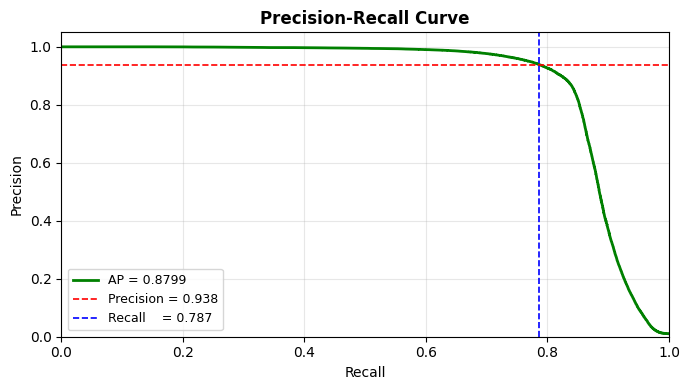

In [74]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
 
y_pred_prob = model.predict(X_test).flatten()
y_true_roc  = (Y_test > 0.5).astype(np.uint8).flatten()
 
prec_curve, rec_curve, _ = precision_recall_curve(y_true_roc, y_pred_prob)
ap = average_precision_score(y_true_roc, y_pred_prob)
 
plt.figure(figsize=(7, 4))
plt.plot(rec_curve, prec_curve, color='green', lw=2, label=f'AP = {ap:.4f}')
plt.axhline(y=precision, color='red',  linestyle='--', lw=1.2, label=f'Precision = {precision:.3f}')
plt.axvline(x=recall,    color='blue', linestyle='--', lw=1.2, label=f'Recall    = {recall:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.tight_layout()
plt.savefig('plot6_precision_recall.png', dpi=150)
plt.show()
 

In [76]:
print("=" * 40)
print("        FINAL RESULTS SUMMARY")
print("=" * 40)
print(f"  Dice Coefficient : {test_dice:.4f}  ← PRIMARY")
print(f"  IoU Score        : {test_iou:.4f}  ← SECONDARY")
print(f"  F1 Score         : {f1:.4f}")
print(f"  Precision        : {precision:.4f}")
print(f"  Recall           : {recall:.4f}")
print(f"  Pixel Accuracy   : {accuracy:.4f}")
print("=" * 40)
if test_dice >= 0.85:
    print("  Performance : Excellent segmentation")
elif test_dice >= 0.75:
    print("  Performance : Good segmentation")
else:
    print("  Performance : Needs improvement")
print("=" * 40)
 

        FINAL RESULTS SUMMARY
  Dice Coefficient : 0.8558  ← PRIMARY
  IoU Score        : 0.7480  ← SECONDARY
  F1 Score         : 0.8558
  Precision        : 0.9382
  Recall           : 0.7868
  Pixel Accuracy   : 0.9973
  Performance : Excellent segmentation
